# Interval training analysis: 3 x 5 min

Parses the Strava GPX export in this folder, derives pace from GPS positions, detects the hard interval blocks automatically and visualizes the session.

Only the standard library plus pandas, numpy and matplotlib are needed (no `gpxpy`).

In [1]:
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

GPX_FILE = Path("data/3_x_5min.gpx")

# Colors: categorical slots from a palette validated for color-vision deficiency
C_BLUE, C_ORANGE, C_AQUA, C_YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
C_TEXT, C_MUTED, C_GRID = "#0b0b0b", "#52514e", "#e6e5e1"

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": C_GRID, "axes.grid": True, "grid.color": C_GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": C_MUTED, "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "axes.titlecolor": C_TEXT, "axes.titlelocation": "left", "axes.titleweight": "bold",
    "axes.axisbelow": True, "font.size": 10,
})

## 1. Parse the GPX file

In [2]:
NS = {
    "g": "http://www.topografix.com/GPX/1/1",
    "tpx": "http://www.garmin.com/xmlschemas/TrackPointExtension/v1",
}

def read_gpx(path: Path) -> pd.DataFrame:
    root = ET.parse(path).getroot()
    rows = []
    for pt in root.iter(f"{{{NS['g']}}}trkpt"):
        cad = pt.find(".//tpx:cad", NS)
        hr = pt.find(".//tpx:hr", NS)
        rows.append({
            "time": pd.Timestamp(pt.findtext("g:time", namespaces=NS)),
            "lat": float(pt.get("lat")),
            "lon": float(pt.get("lon")),
            "ele": float(pt.findtext("g:ele", default="nan", namespaces=NS)),
            "cadence": float(cad.text) if cad is not None else np.nan,
            "hr": float(hr.text) if hr is not None else np.nan,
        })
    df = pd.DataFrame(rows)
    df["t"] = (df["time"] - df["time"].iloc[0]).dt.total_seconds()
    return df

df = read_gpx(GPX_FILE)
activity_name = ET.parse(GPX_FILE).getroot().findtext(".//g:name", namespaces=NS)
print(f"{activity_name}: {len(df)} track points, {df['t'].iloc[-1]/60:.1f} min, "
      f"started {df['time'].iloc[0]:%Y-%m-%d %H:%M} UTC")
df.head()

3 x 5min: 1983 track points, 33.2 min, started 2026-09-08 18:37 UTC


,time,lat,lon,ele,cadence,hr,t
0,2026-09-08 18:37:27+00:00,51.047585,3.712648,8.3,0.0,NaN,0.0
1,2026-09-08 18:37:28+00:00,51.047596,3.712610,8.3,0.0,NaN,1.0
2,2026-09-08 18:37:29+00:00,51.047607,3.712570,8.3,69.0,NaN,2.0
3,2026-09-08 18:37:31+00:00,51.047628,3.712531,8.3,69.0,NaN,4.0
4,2026-09-08 18:37:32+00:00,51.047643,3.712514,8.3,69.0,NaN,5.0


## 2. Distance, speed and pace

Distance between consecutive points comes from the haversine formula. Raw 1 Hz GPS speed is noisy, so speed is smoothed with a centered 15 s rolling mean before converting to pace (min/km).

In [3]:
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6_371_000.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi, dlmb = p2 - p1, np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

step_m = np.r_[0.0, haversine_m(df.lat.values[:-1], df.lon.values[:-1], df.lat.values[1:], df.lon.values[1:])]
step_s = np.r_[1.0, np.diff(df["t"].values)]
df["dist_m"] = np.cumsum(step_m)
df["speed_raw"] = step_m / step_s

SMOOTH = "15s"
tindex = pd.to_timedelta(df["t"], unit="s")
df["speed"] = pd.Series(df["speed_raw"].values, index=tindex).rolling(SMOOTH, center=True).mean().values
df["pace_min_km"] = 1000 / df["speed"] / 60          # minutes per km
df["cadence_spm"] = df["cadence"] * 2                 # Garmin cadence is per leg; steps/min is x2

def fmt_pace(minutes: float) -> str:
    if not np.isfinite(minutes) or minutes < 0:
        return "-"
    m, s = divmod(round(minutes * 60), 60)
    return f"{int(m)}:{int(s):02d}"

print(f"Total distance : {df.dist_m.iloc[-1]/1000:.2f} km")
print(f"Total time     : {fmt_pace(df.t.iloc[-1]/60)} min")
print(f"Average pace   : {fmt_pace(df.t.iloc[-1] / 60 / (df.dist_m.iloc[-1]/1000))} /km")

Total distance : 5.63 km
Total time     : 33:10 min
Average pace   : 5:54 /km


## 3. Detect the intervals

The speed distribution is bimodal: hard running vs. easy running and walking. The threshold is placed between the two modes with a simple two-means split, then every continuous stretch above the threshold that lasts at least 2 minutes is treated as a work interval. Short dips (GPS noise, a corner) inside an interval are bridged.

In [4]:
def two_means_threshold(x: np.ndarray, iters: int = 50) -> float:
    x = x[np.isfinite(x)]
    lo, hi = np.percentile(x, 20), np.percentile(x, 90)
    for _ in range(iters):
        thr = (lo + hi) / 2
        lo, hi = x[x < thr].mean(), x[x >= thr].mean()
    return (lo + hi) / 2

def detect_intervals(df: pd.DataFrame, min_work_s=120, max_gap_s=20) -> pd.DataFrame:
    thr = two_means_threshold(df["speed"].values)
    fast = (df["speed"] >= thr).values
    t = df["t"].values

    # Contiguous runs of "fast"
    edges = np.flatnonzero(np.diff(np.r_[0, fast.astype(int), 0]))
    runs = [(edges[i], edges[i + 1] - 1) for i in range(0, len(edges), 2)]

    # Bridge short gaps
    merged = []
    for s, e in runs:
        if merged and t[s] - t[merged[-1][1]] <= max_gap_s:
            merged[-1] = (merged[-1][0], e)
        else:
            merged.append((s, e))

    rows = []
    for s, e in merged:
        dur = t[e] - t[s]
        if dur < min_work_s:
            continue
        seg = df.iloc[s:e + 1]
        dist = seg.dist_m.iloc[-1] - seg.dist_m.iloc[0]
        rows.append({
            "start_idx": s, "end_idx": e,
            "start_s": t[s], "end_s": t[e], "duration_s": dur,
            "distance_m": dist,
            "avg_speed": dist / dur,
            "avg_pace_min_km": dur / 60 / (dist / 1000),
            "avg_cadence_spm": seg.cadence_spm.mean(),
            "elev_gain_m": np.clip(np.diff(seg.ele), 0, None).sum(),
        })
    out = pd.DataFrame(rows)
    out.index = [f"Rep {i+1}" for i in range(len(out))]
    out.attrs["threshold"] = thr
    return out

intervals = detect_intervals(df)
THR = intervals.attrs["threshold"]
print(f"Speed threshold: {THR:.2f} m/s  ({fmt_pace(1000/THR/60)} /km)")
print(f"Detected {len(intervals)} work intervals\n")

summary = intervals.assign(
    start=intervals.start_s.map(lambda s: fmt_pace(s / 60)),
    duration=intervals.duration_s.map(lambda s: fmt_pace(s / 60)),
    distance_km=(intervals.distance_m / 1000).round(3),
    pace=intervals.avg_pace_min_km.map(fmt_pace),
    cadence_spm=intervals.avg_cadence_spm.round(0).astype(int),
    elev_gain_m=intervals.elev_gain_m.round(1),
)[["start", "duration", "distance_km", "pace", "cadence_spm", "elev_gain_m"]]
summary

Speed threshold: 2.86 m/s  (5:49 /km)
Detected 3 work intervals



,start,duration,distance_km,pace,cadence_spm,elev_gain_m
Rep 1,12:45,4:55,1.130,4:21,145,1.9
Rep 2,20:02,5:10,1.175,4:24,144,0.7
Rep 3,27:28,5:27,1.266,4:18,146,0.9


### Recovery between the reps

In [5]:
rec = []
for i in range(len(intervals) - 1):
    a, b = intervals.iloc[i], intervals.iloc[i + 1]
    seg = df.iloc[int(a.end_idx):int(b.start_idx) + 1]
    dist = seg.dist_m.iloc[-1] - seg.dist_m.iloc[0]
    dur = b.start_s - a.end_s
    rec.append({"between": f"{intervals.index[i]} -> {intervals.index[i+1]}",
                "duration": fmt_pace(dur / 60), "distance_m": round(dist),
                "pace": fmt_pace(dur / 60 / (dist / 1000))})
recovery = pd.DataFrame(rec).set_index("between")
recovery

,duration,distance_m,pace
between,,,
Rep 1 -> Rep 2,2:22,211,11:12
Rep 2 -> Rep 3,2:16,206,11:00


## 4. Visualize

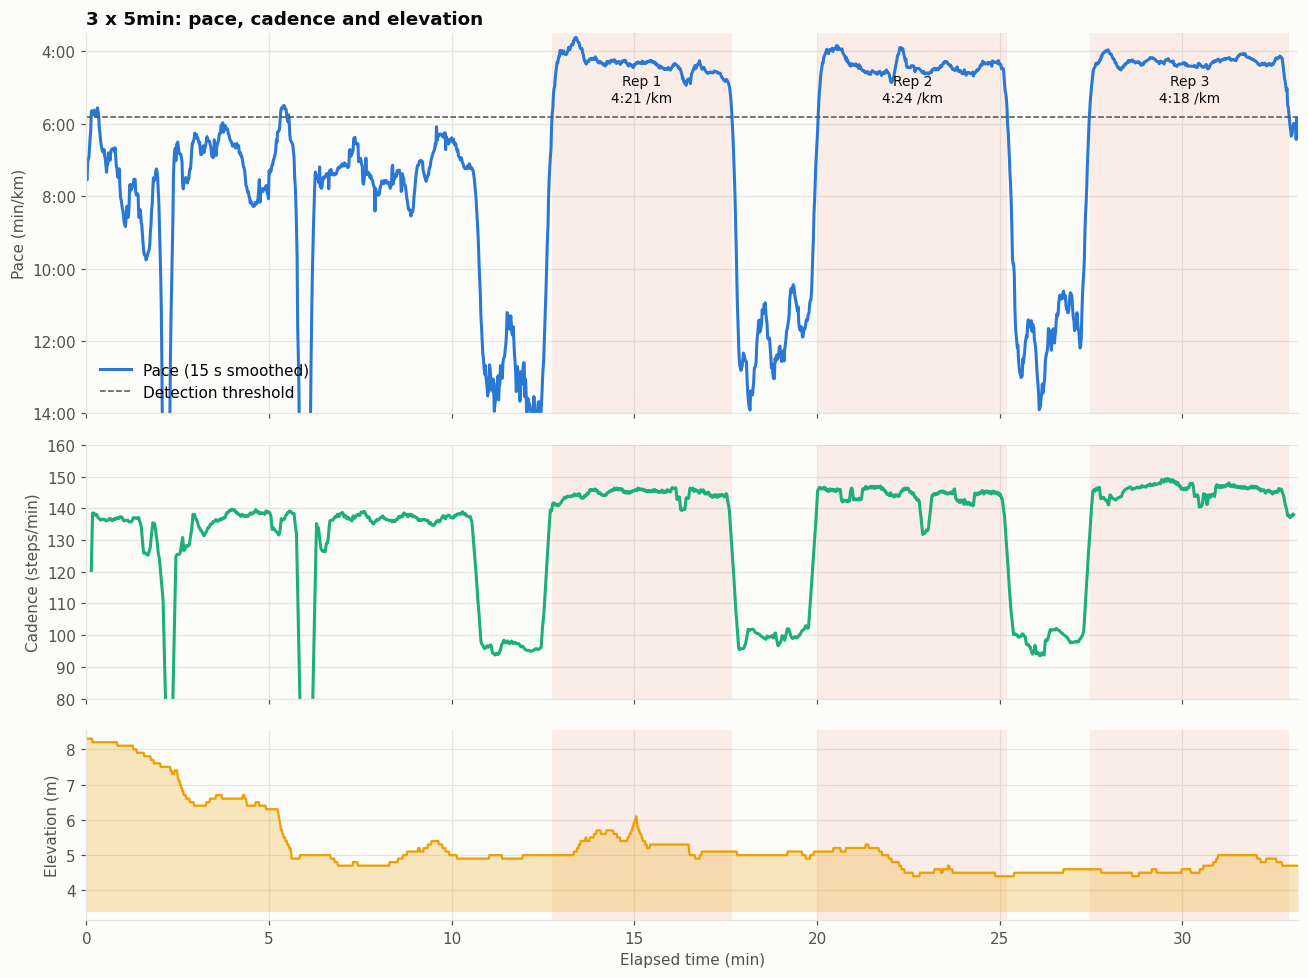

In [6]:
# Label each point with its phase
df["phase"] = "easy"
for name, r in intervals.iterrows():
    df.loc[int(r.start_idx):int(r.end_idx), "phase"] = name
df["is_work"] = df["phase"].str.startswith("Rep")

def shade_intervals(ax):
    for name, r in intervals.iterrows():
        ax.axvspan(r.start_s / 60, r.end_s / 60, color=C_ORANGE, alpha=0.10, lw=0)

pace_fmt = FuncFormatter(lambda v, _: fmt_pace(v))
tmin = df["t"] / 60

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, gridspec_kw={"height_ratios": [3, 2, 1.5]})

# Pace (inverted: faster is higher)
ax = axes[0]
shade_intervals(ax)
ax.plot(tmin, df["pace_min_km"], color=C_BLUE, lw=2, label="Pace (15 s smoothed)")
ax.axhline(1000 / THR / 60, color=C_MUTED, lw=1, ls="--", label="Detection threshold")
for name, r in intervals.iterrows():
    ax.text((r.start_s + r.end_s) / 120, 5.05, f"{name}\n{fmt_pace(r.avg_pace_min_km)} /km",
            ha="center", va="center", fontsize=9, color=C_TEXT)
ax.set_ylim(14, 3.5)
ax.yaxis.set_major_formatter(pace_fmt)
ax.set_ylabel("Pace (min/km)")
ax.set_title(f"{activity_name}: pace, cadence and elevation")
ax.legend(loc="lower left", frameon=False)

# Cadence
ax = axes[1]
shade_intervals(ax)
ax.plot(tmin, df["cadence_spm"].rolling(15, center=True).mean(), color=C_AQUA, lw=2)
ax.set_ylabel("Cadence (steps/min)")
ax.set_ylim(80, 160)

# Elevation
ax = axes[2]
shade_intervals(ax)
ax.fill_between(tmin, df["ele"], df["ele"].min() - 1, color=C_YELLOW, alpha=0.25, lw=0)
ax.plot(tmin, df["ele"], color=C_YELLOW, lw=1.5)
ax.set_ylabel("Elevation (m)")
ax.set_xlabel("Elapsed time (min)")
ax.set_xlim(0, tmin.iloc[-1])

fig.tight_layout()
plt.show()

### Pace within each rep

Each rep is aligned to its own start so pacing strategy can be compared rep by rep.

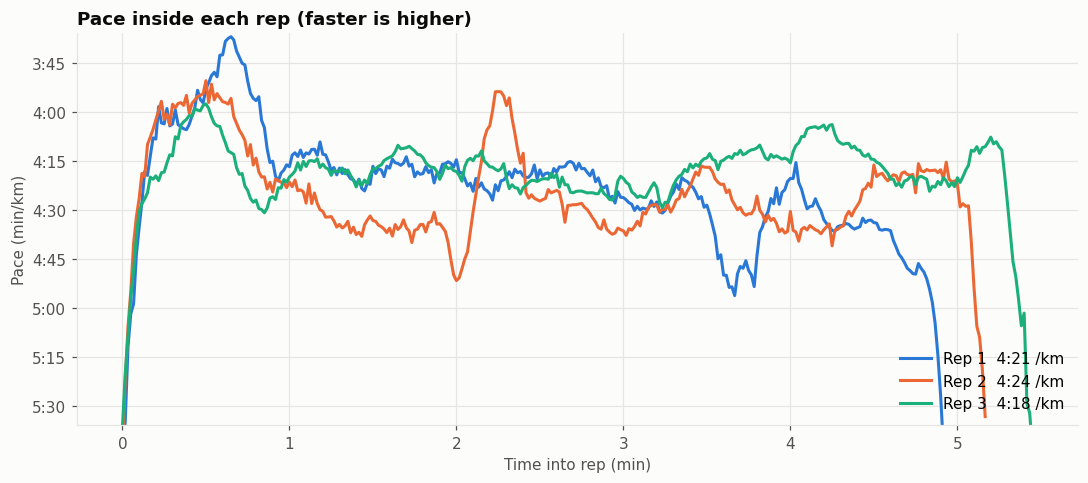

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
rep_colors = [C_BLUE, C_ORANGE, C_AQUA, C_YELLOW]
for (name, r), color in zip(intervals.iterrows(), rep_colors):
    seg = df.iloc[int(r.start_idx):int(r.end_idx) + 1]
    x = (seg["t"] - r.start_s) / 60
    ax.plot(x, seg["pace_min_km"], color=color, lw=2, label=f"{name}  {fmt_pace(r.avg_pace_min_km)} /km")
ax.set_ylim(5.6, 3.6)
ax.yaxis.set_major_formatter(pace_fmt)
ax.set_xlabel("Time into rep (min)")
ax.set_ylabel("Pace (min/km)")
ax.set_title("Pace inside each rep (faster is higher)")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

### Rep summary

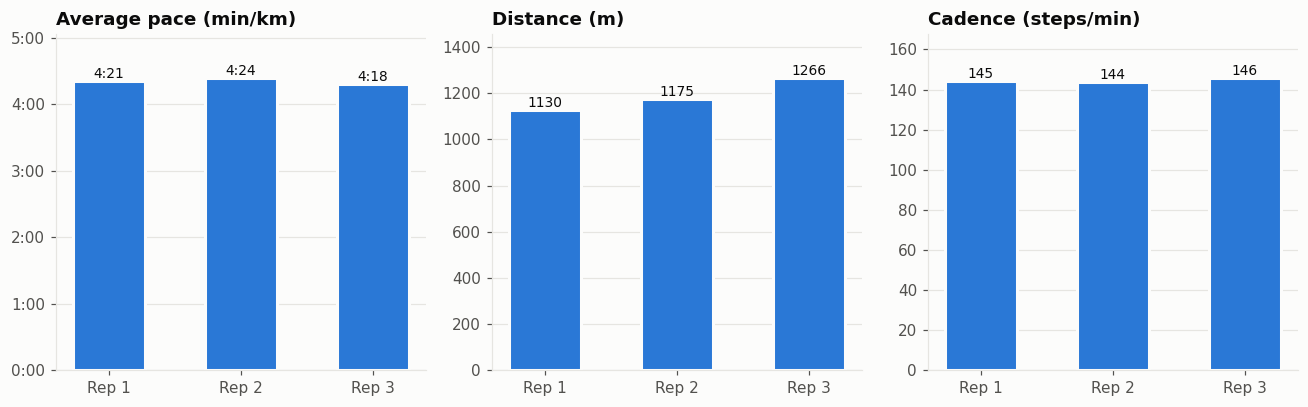

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
x = np.arange(len(intervals))
labels = intervals.index

def bars(ax, values, title, fmt, ylim=None):
    b = ax.bar(x, values, width=0.55, color=C_BLUE, edgecolor="#fcfcfb", linewidth=2)
    for rect, v in zip(b, values):
        ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height(), fmt(v),
                ha="center", va="bottom", fontsize=9, color=C_TEXT)
    ax.set_xticks(x, labels)
    ax.set_title(title)
    ax.grid(axis="x", visible=False)
    if ylim: ax.set_ylim(*ylim)

bars(axes[0], intervals.avg_pace_min_km, "Average pace (min/km)", fmt_pace,
     ylim=(0, intervals.avg_pace_min_km.max() * 1.15))
axes[0].yaxis.set_major_formatter(pace_fmt)
bars(axes[1], intervals.distance_m, "Distance (m)", lambda v: f"{v:.0f}",
     ylim=(0, intervals.distance_m.max() * 1.15))
bars(axes[2], intervals.avg_cadence_spm, "Cadence (steps/min)", lambda v: f"{v:.0f}",
     ylim=(0, intervals.avg_cadence_spm.max() * 1.15))
fig.tight_layout()
plt.show()

### Speed distribution and threshold

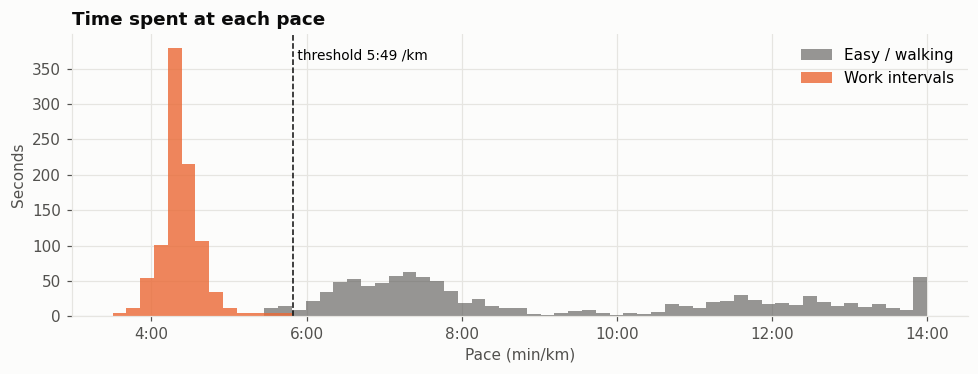

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.5))
pace_bins = np.linspace(3.5, 14, 60)
ax.hist(df.loc[~df.is_work, "pace_min_km"].clip(upper=14), bins=pace_bins, color=C_MUTED, alpha=0.6, label="Easy / walking")
ax.hist(df.loc[df.is_work, "pace_min_km"].clip(upper=14), bins=pace_bins, color=C_ORANGE, alpha=0.8, label="Work intervals")
ax.axvline(1000 / THR / 60, color=C_TEXT, lw=1, ls="--")
ax.text(1000 / THR / 60, ax.get_ylim()[1] * 0.95, f" threshold {fmt_pace(1000/THR/60)} /km", va="top", fontsize=9)
ax.xaxis.set_major_formatter(pace_fmt)
ax.set_xlabel("Pace (min/km)")
ax.set_ylabel("Seconds")
ax.set_title("Time spent at each pace")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### Route map

GPS track colored by phase. The route is projected to meters relative to the start so the aspect ratio is true.

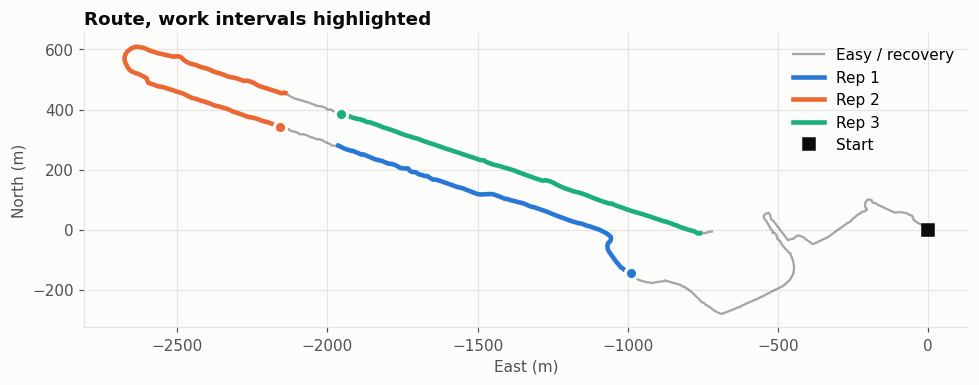

In [10]:
lat0 = df.lat.mean()
xm = (df.lon - df.lon.iloc[0]) * 111_320 * np.cos(np.radians(lat0))
ym = (df.lat - df.lat.iloc[0]) * 110_540

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(xm, ym, color=C_MUTED, lw=1.5, alpha=0.5, label="Easy / recovery")
for (name, r), color in zip(intervals.iterrows(), rep_colors):
    sl = slice(int(r.start_idx), int(r.end_idx) + 1)
    ax.plot(xm[sl], ym[sl], color=color, lw=3, label=name)
    ax.plot(xm[sl].iloc[0], ym[sl].iloc[0], "o", color=color, ms=8, mec="#fcfcfb", mew=2)
ax.plot(xm.iloc[0], ym.iloc[0], "s", color=C_TEXT, ms=8, label="Start")
ax.set_aspect("equal")
ax.set_xlabel("East (m)"); ax.set_ylabel("North (m)")
ax.set_title("Route, work intervals highlighted")
ax.legend(frameon=False, loc="best")
fig.tight_layout()
plt.show()

## 5. Export

Per-second data with the phase label, plus the interval table, for reuse elsewhere.

In [11]:
out_cols = ["time", "t", "lat", "lon", "ele", "dist_m", "speed", "pace_min_km", "cadence_spm", "phase"]
df[out_cols].to_csv("data/3_x_5min_processed.csv", index=False)
intervals.to_csv("data/3_x_5min_intervals.csv")
print("Wrote data/3_x_5min_processed.csv and data/3_x_5min_intervals.csv")

Wrote data/3_x_5min_processed.csv and data/3_x_5min_intervals.csv
